In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

##  Install gdown

In [2]:
!pip install gdown

## Download Dataset from Google Drive

In [ ]:
import gdown
import os

# Output directory in Kaggle
output_dir = "/kaggle/working/"
os.makedirs(output_dir, exist_ok=True)

# File IDs extracted from the Drive links
file_ids = {
    "file1": "1eKbH2sGY7UTlimP0NLLFe6ITSzrnoOH9",
    "file2": "1YNCWB66_gKX9jNWMB3JUeqUeNCYsEqXb",
    "file3": "1i37SCtY2fNaPIyfgKAGxqNHgqpIUP4rO",
}

for name, file_id in file_ids.items():
    url = f"https://drive.google.com/uc?id={file_id}"
    output_path = os.path.join(output_dir, name)  # gdown will auto-detect filename
    gdown.download(url, output_path, quiet=False, fuzzy=True)

print("All files downloaded!")

Downloading...
From (original): https://drive.google.com/uc?id=1eKbH2sGY7UTlimP0NLLFe6ITSzrnoOH9
From (redirected): https://drive.google.com/uc?id=1eKbH2sGY7UTlimP0NLLFe6ITSzrnoOH9&confirm=t&uuid=88db0953-6939-49df-bd47-8db63d1aa241
To: /kaggle/working/file1
100%|██████████| 6.90G/6.90G [01:39<00:00, 69.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1YNCWB66_gKX9jNWMB3JUeqUeNCYsEqXb
To: /kaggle/working/file2
100%|██████████| 853/853 [00:00<00:00, 1.53MB/s]
Downloading...
From: https://drive.google.com/uc?id=1i37SCtY2fNaPIyfgKAGxqNHgqpIUP4rO
To: /kaggle/working/file3
100%|██████████| 2.01k/2.01k [00:00<00:00, 6.44MB/s]

All files downloaded!


## Verify Downloads

In [4]:
import os

for f in ["file1", "file2", "file3"]:
    path = f"/kaggle/working/{f}"
    size = os.path.getsize(path) / 1e6
    print(f"{f}: {size:.1f} MB")

# Also check magic bytes to confirm file type
for f in ["file1", "file2", "file3"]:
    with open(f"/kaggle/working/{f}", "rb") as fh:
        print(f"{f} magic bytes: {fh.read(4).hex()}")

file1: 6904.2 MB
file2: 0.0 MB
file3: 0.0 MB
file1 magic bytes: 1f8b0800
file2 magic bytes: 616c6f6f
file3 magic bytes: 63617465


## Extract the Dataset

In [5]:
import tarfile, os

# file1 is the big tar.gz (6.90G)
with tarfile.open("/kaggle/working/file1", "r:gz") as tar:
    tar.extractall("/kaggle/working/my-dataset", filter="data")  # ✅ fixes DeprecationWarning
    print("✅ Extracted:")
    for name in tar.getnames()[:20]:  # first 20 only to avoid spam
        print(f"  {name}")

✅ Extracted:
  khana
  khana/vada pav
  khana/murukku
  khana/jalebi
  khana/biryani
  khana/misal pav
  khana/mysore pak
  khana/masala papad
  khana/poha
  khana/grilled sandwich
  khana/samosa
  khana/rava dosa
  khana/balushahi
  khana/bhindi masala
  khana/chapati
  khana/paniyaram
  khana/banana chips
  khana/idiyappam
  khana/._.DS_Store
  khana/.DS_Store


## Explore Folder Structure

In [6]:
import os
for root, dirs, files in os.walk("/kaggle/working/my-dataset"):
    level = root.replace("/kaggle/working/my-dataset", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # only show files 2 levels deep
        for file in files[:5]:
            print(f"{indent}  {file}")

my-dataset/
  khana/
    .DS_Store
    ._.DS_Store
    phirni/
    fish curry/
    gajar ka halwa/
    navratan korma/
    puri bhaji/
    palak paneer/
    idiyappam/
    paneer pizza/
    thukpa/
    neer dosa/
    chivda/
    kulfi/
    paneer masala/
    falooda/
    paniyaram/
    mysore pak/
    khakhra/
    jalebi/
    amritsari kulcha/
    dhokla/
    seekh kebab/
    chapati/
    moong dal halwa/
    aloo methi/
    besan laddu/
    rajma chawal/
    chikki/
    pav bhaji/
    thali/
    chole bhature/
    gujhia/
    masala dosa/
    chicken wings/
    chana masala/
    aloo paratha/
    sev puri/
    steamed momo/
    uttapam/
    biryani/
    chaas/
    poha/
    garlic naan/
    garlic bread/
    kaju katli/
    pani puri/
    sabudana khichdi/
    kheer/
    medu vada/
    patrode/
    set dosa/
    vada pav/
    dal khichdi/
    gulab jamun/
    anda curry/
    chicken pizza/
    idli/
    bhindi masala/
    murukku/
    rasgulla/
    pongal/
    hara bhara kabab/
    gr

##  Quick Directory Listing

In [7]:
ls /kaggle/working/my-dataset/ && ls /kaggle/working/my-dataset/khana

khana/
'aloo gobi'	     dabeli		'margherita pizza'  'pepperoni pizza'
'aloo methi'	    'dal khichdi'	'masala dosa'	     phirni
'aloo mutter'	     dhokla		'masala papad'	     poha
'aloo paratha'	     falooda		'medu vada'	     pongal
'amritsari kulcha'  'fish curry'	'misal pav'	    'puri bhaji'
'anda curry'	    'gajar ka halwa'	 modak		    'rajma chawal'
 balushahi	    'garlic bread'	'moong dal halwa'    rasgulla
'banana chips'	    'garlic naan'	 murukku	    'rava dosa'
'besan laddu'	     ghevar		'mysore pak'	    'sabudana khichdi'
'bhindi masala'     'grilled sandwich'	'navratan korma'    'sabudana vada'
 biryani	     gujhia		'neer dosa'	     samosa
'boondi laddu'	    'gulab jamun'	'onion pakoda'	    'seekh kebab'
 chaas		    'hara bhara kabab'	'palak paneer'	    'set dosa'
'chana masala'	     idiyappam		'paneer masala'     'sev puri'
 chapati	     idli		'paneer pizza'	     solkadhi
'chicken pizza'      jalebi		'pani puri'	    'steamed momo'
'chicken wings'     'kaju katli'	 paniyaram	 

## Install Libraries & Check Hardware

In [8]:
# ── 1. Install & Imports ──────────────────────────────────────────────────────
!pip install timm --quiet

import os, random, time, copy, json
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import torchvision.transforms as T
import timm

print(f"PyTorch  : {torch.__version__}")
print(f"TIMM     : {timm.__version__}")
print(f"CUDA     : {torch.cuda.is_available()} — {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

PyTorch  : 2.10.0+cu128
TIMM     : 1.0.25
CUDA     : True — Tesla T4


## Configuration Dictionary 

In [9]:
# ── 2. Config ─────────────────────────────────────────────────────────────────
CFG = dict(
    # Paths
    data_dir     = "/kaggle/working/my-dataset/khana",
    save_dir     = "/kaggle/working/efficientnetv2_s",

    # Model
    # EfficientNetV2-S trained on IN-21k then fine-tuned on IN-1k (best transfer)
    model_name   = "tf_efficientnetv2_s.in21k_ft_in1k",
    img_size     = 300,   # native EfficientNetV2-S size; safe on P100 @ batch 48
    num_classes  = None,  # auto-detected from dataset
    drop_rate    = 0.2,
    drop_path_rate = 0.1,

    # Training
    epochs_frozen = 3,    # head-only warmup (reduced for time)
    epochs_full   = 7,    # full network fine-tune (reduced for time)
    batch_size    = 48,   # safe for P100 @ 300px; reduce to 32 if OOM
    num_workers   = 0,
    seed          = 42,

    # Optimizer
    lr_head       = 1e-3,
    lr_backbone   = 1e-5,
    lr_head_ft    = 1e-4,
    weight_decay  = 1e-4,

    # Scheduler
    warmup_epochs = 3,
    min_lr        = 1e-7,

    # Regularisation
    label_smoothing = 0.1,
    mixup_alpha     = 0.4,
    cutmix_alpha    = 1.0,   # EfficientNet benefits from CutMix too
    val_split       = 0.15,
)

os.makedirs(CFG["save_dir"], exist_ok=True)

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG["seed"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## Dataset Preparation (Paths & Labels)

In [10]:
# ── 3. Dataset & Splits ───────────────────────────────────────────────────────
data_dir = Path(CFG["data_dir"])
class_names = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
class_to_idx = {c: i for i, c in enumerate(class_names)}
CFG["num_classes"] = len(class_names)
print(f"Classes found: {CFG['num_classes']}")

all_paths, all_labels = [], []
for cls in class_names:
    for img_path in (data_dir / cls).rglob("*"):
        if img_path.is_file() and not img_path.name.startswith("._"):  # skip macOS metadata
            all_paths.append(str(img_path))
            all_labels.append(class_to_idx[cls])

print(f"Total images : {len(all_paths)}")

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels,
    test_size=CFG["val_split"],
    stratify=all_labels,
    random_state=CFG["seed"]
)
print(f"Train: {len(train_paths)} | Val: {len(val_paths)}")

with open(os.path.join(CFG["save_dir"], "class_to_idx.json"), "w") as f:
    json.dump(class_to_idx, f, indent=2)
print("Saved class_to_idx.json")
# ── Scan and remove corrupt images ───────────────────────────────────────────
def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

print("Scanning for corrupt images (this may take a minute)...")

train_mask = [is_valid_image(p) for p in train_paths]
val_mask   = [is_valid_image(p) for p in val_paths]

removed_train = sum(1 for v in train_mask if not v)
removed_val   = sum(1 for v in val_mask   if not v)

train_paths  = [p for p, v in zip(train_paths,  train_mask) if v]
train_labels = [l for l, v in zip(train_labels, train_mask) if v]
val_paths    = [p for p, v in zip(val_paths,    val_mask)   if v]
val_labels   = [l for l, v in zip(val_labels,   val_mask)   if v]

print(f"Removed {removed_train} corrupt train images, {removed_val} corrupt val images")
print(f"Clean — Train: {len(train_paths)} | Val: {len(val_paths)}")

with open(os.path.join(CFG["save_dir"], "class_to_idx.json"), "w") as f:
    json.dump(class_to_idx, f, indent=2)
print("Saved class_to_idx.json")

Classes found: 80
Total images : 131819
Train: 112046 | Val: 19773
Saved class_to_idx.json
Scanning for corrupt images (this may take a minute)...
Removed 0 corrupt train images, 0 corrupt val images
Clean — Train: 112046 | Val: 19773
Saved class_to_idx.json


## Data Augmentation & Transforms

In [11]:
# ── 4. Transforms ─────────────────────────────────────────────────────────────
# EfficientNetV2 uses different normalisation stats from standard ImageNet
IMG_MEAN = [0.5, 0.5, 0.5]
IMG_STD  = [0.5, 0.5, 0.5]
S = CFG["img_size"]

train_tfm = T.Compose([
    T.RandomResizedCrop(S, scale=(0.65, 1.0), ratio=(0.75, 1.33),
                        interpolation=T.InterpolationMode.BICUBIC),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.05),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.08),
    T.RandomGrayscale(p=0.05),
    T.RandomApply([T.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))], p=0.15),
    T.ToTensor(),
    T.Normalize(IMG_MEAN, IMG_STD),
    T.RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3)),
])

val_tfm = T.Compose([
    T.Resize(int(S * 1.07), interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(S),
    T.ToTensor(),
    T.Normalize(IMG_MEAN, IMG_STD),
])
print("Transforms defined. Image size:", S)

Transforms defined. Image size: 300


## Custom Dataset Class

In [12]:
# ── 5. Dataset class ──────────────────────────────────────────────────────────
class FoodDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
        except Exception:
            # Return a blank image if file is corrupt
            img = Image.new("RGB", (CFG["img_size"], CFG["img_size"]))
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

train_ds = FoodDataset(train_paths, train_labels, train_tfm)
val_ds   = FoodDataset(val_paths,   val_labels,   val_tfm)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=CFG["num_workers"], pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 2334 | Val batches: 412


## Mixup & CutMix

In [13]:
# ── 6. Mixup + CutMix augmentation ───────────────────────────────────────────
def rand_bbox(size, lam):
    W, H = size[2], size[3]
    cut_rat = np.sqrt(1.0 - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)
    return x1, y1, x2, y2

def cutmix_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    rand_index = torch.randperm(x.size(0)).to(x.device)
    y_a, y_b = y, y[rand_index]
    x1, y1, x2, y2 = rand_bbox(x.size(), lam)
    x[:, :, y1:y2, x1:x2] = x[rand_index, :, y1:y2, x1:x2]
    lam = 1 - ((x2 - x1) * (y2 - y1)) / (x.size(-1) * x.size(-2))
    return x, y_a, y_b, lam

def mixup_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, y, y[index], lam

def mixed_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

## Build the Model

In [14]:
# ── 7. Model ──────────────────────────────────────────────────────────────────
def build_model(freeze_backbone=True):
    model = timm.create_model(
        CFG["model_name"],
        pretrained=True,
        num_classes=CFG["num_classes"],
        drop_rate=CFG["drop_rate"],
        drop_path_rate=CFG["drop_path_rate"],
    )
    if freeze_backbone:
        for name, param in model.named_parameters():
            if "classifier" not in name:  # EfficientNet head is called 'classifier'
                param.requires_grad = False
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"[Frozen] Trainable params: {trainable:,}")
    else:
        for param in model.parameters():
            param.requires_grad = True
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"[Unfrozen] Trainable params: {trainable:,}")
    return model.to(DEVICE)

model = build_model(freeze_backbone=True)

# Print model head name for verification
data_cfg = timm.data.resolve_model_data_config(model)
print(f"Model    : {CFG['model_name']}")
print(f"Input    : {data_cfg}")

model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

[Frozen] Trainable params: 102,480
Model    : tf_efficientnetv2_s.in21k_ft_in1k
Input    : {'input_size': (3, 300, 300), 'interpolation': 'bicubic', 'mean': (0.5, 0.5, 0.5), 'std': (0.5, 0.5, 0.5), 'crop_pct': 1.0, 'crop_mode': 'center'}


## Optimizer & Scheduler & Train & Validation Functions

In [15]:
# ── 8. Training utilities ─────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=CFG["label_smoothing"]).to(DEVICE)
scaler    = GradScaler()

def get_optimizer(model, phase="frozen"):
    if phase == "frozen":
        params = [p for p in model.parameters() if p.requires_grad]
        return optim.AdamW(params, lr=CFG["lr_head"], weight_decay=CFG["weight_decay"])
    else:
        # Differential LR: classifier gets 10× more than backbone
        classifier_params = [p for n, p in model.named_parameters() if "classifier" in n]
        backbone_params   = [p for n, p in model.named_parameters() if "classifier" not in n]
        return optim.AdamW([
            {"params": backbone_params, "lr": CFG["lr_backbone"]},
            {"params": classifier_params, "lr": CFG["lr_head_ft"]},
        ], weight_decay=CFG["weight_decay"])

def get_scheduler(optimizer, epochs, warmup=3):
    """Cosine decay with linear warmup."""
    def lr_lambda(epoch):
        if epoch < warmup:
            return (epoch + 1) / warmup
        progress = (epoch - warmup) / max(1, epochs - warmup)
        return max(CFG["min_lr"] / CFG["lr_head"], 0.5 * (1 + np.cos(np.pi * progress)))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def train_epoch(model, loader, optimizer, epoch, use_augmix=True):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    t0 = time.time()
    for step, (imgs, labels) in enumerate(loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        if use_augmix:
            # Randomly choose Mixup or CutMix (50/50)
            if random.random() < 0.5:
                imgs, y_a, y_b, lam = mixup_data(imgs, labels, CFG["mixup_alpha"])
            else:
                imgs, y_a, y_b, lam = cutmix_data(imgs, labels, CFG["cutmix_alpha"])
        optimizer.zero_grad()
        with autocast():
            logits = model(imgs)
            if use_augmix:
                loss = mixed_criterion(criterion, logits, y_a, y_b, lam)
            else:
                loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        if not use_augmix:
            preds = logits.argmax(1)
            correct += (preds == labels).sum().item()
        total += imgs.size(0)
        if (step + 1) % 50 == 0:
            print(f"  step {step+1}/{len(loader)} | loss {total_loss/total:.4f} | "
                  f"elapsed {time.time()-t0:.1f}s")
    avg_loss = total_loss / total
    acc = correct / total if not use_augmix else float('nan')
    return avg_loss, acc


@torch.no_grad()
def val_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with autocast():
            logits = model(imgs)
            loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        preds   = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
    return total_loss / total, correct / total

/tmp/ipykernel_23/2607432864.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()


## Phase 1: Head-Only Training

In [16]:
# ── 9. Phase 1 — Head-only Training ──────────────────────────────────────────

# Filter out any macOS metadata files that slipped through
train_paths[:] = [p for p in train_paths if not os.path.basename(p).startswith("._")]
train_labels[:] = [l for p, l in zip(train_paths, train_labels) if not os.path.basename(p).startswith("._")]
val_paths[:]   = [p for p in val_paths   if not os.path.basename(p).startswith("._")]
val_labels[:]  = [l for p, l in zip(val_paths, val_labels)   if not os.path.basename(p).startswith("._")]

print(f"After filter — Train: {len(train_paths)} | Val: {len(val_paths)}")

print("=" * 60)
print("PHASE 1: Training classifier with frozen backbone")
print("=" * 60)

optimizer1 = get_optimizer(model, phase="frozen")
scheduler1 = get_scheduler(optimizer1, CFG["epochs_frozen"], warmup=1)
best_val_acc = 0.0
history = []

for epoch in range(CFG["epochs_frozen"]):
    t_start = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer1, epoch, use_augmix=False)
    vl_loss, vl_acc = val_epoch(model, val_loader)
    scheduler1.step()
    lr_now = scheduler1.get_last_lr()[0]
    elapsed = time.time() - t_start
    print(f"[P1] Epoch {epoch+1:02d}/{CFG['epochs_frozen']} | "
          f"tr_loss {tr_loss:.4f} | vl_loss {vl_loss:.4f} | "
          f"vl_acc {vl_acc*100:.2f}% | lr {lr_now:.2e} | {elapsed:.0f}s")
    history.append({"phase": 1, "epoch": epoch+1, "tr_loss": tr_loss,
                    "vl_loss": vl_loss, "vl_acc": vl_acc})
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(),
                   os.path.join(CFG["save_dir"], "best_phase1.pth"))

print(f"\n✅ Phase 1 best val acc: {best_val_acc*100:.2f}%")

After filter — Train: 112046 | Val: 19773
PHASE 1: Training classifier with frozen backbone


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/tmp/ipykernel_23/2607432864.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  step 50/2334 | loss 4.8485 | elapsed 55.4s
  step 100/2334 | loss 4.2038 | elapsed 106.5s
  step 150/2334 | loss 3.8298 | elapsed 157.4s
  step 200/2334 | loss 3.5898 | elapsed 208.9s
  step 250/2334 | loss 3.4002 | elapsed 262.3s
  step 300/2334 | loss 3.2513 | elapsed 314.6s
  step 350/2334 | loss 3.1497 | elapsed 366.8s
  step 400/2334 | loss 3.0630 | elapsed 418.8s
  step 450/2334 | loss 2.9887 | elapsed 470.5s
  step 500/2334 | loss 2.9270 | elapsed 523.7s
  step 550/2334 | loss 2.8710 | elapsed 575.6s
  step 600/2334 | loss 2.8233 | elapsed 628.4s
  step 650/2334 | loss 2.7772 | elapsed 681.1s
  step 700/2334 | loss 2.7420 | elapsed 734.1s
  step 750/2334 | loss 2.7095 | elapsed 786.7s
  step 800/2334 | loss 2.6776 | elapsed 839.4s
  step 850/2334 | loss 2.6502 | elapsed 893.3s
  step 900/2334 | loss 2.6233 | elapsed 945.9s
  step 950/2334 | loss 2.5990 | elapsed 998.4s
  step 1000/2334 | loss 2.5753 | elapsed 1051.8s
  step 1050/2334 | loss 2.5525 | elapsed 1104.3s
  step 1100

/tmp/ipykernel_23/2607432864.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[P1] Epoch 01/3 | tr_loss 2.2748 | vl_loss 1.5643 | vl_acc 78.75% | lr 1.00e-03 | 2667s
  step 50/2334 | loss 1.9449 | elapsed 51.9s
  step 100/2334 | loss 1.9306 | elapsed 103.4s
  step 150/2334 | loss 1.9581 | elapsed 155.8s
  step 200/2334 | loss 1.9544 | elapsed 208.1s
  step 250/2334 | loss 1.9576 | elapsed 260.6s
  step 300/2334 | loss 1.9529 | elapsed 312.9s
  step 350/2334 | loss 1.9535 | elapsed 365.9s
  step 400/2334 | loss 1.9528 | elapsed 419.1s
  step 450/2334 | loss 1.9457 | elapsed 472.7s
  step 500/2334 | loss 1.9467 | elapsed 526.7s
  step 550/2334 | loss 1.9447 | elapsed 580.3s
  step 600/2334 | loss 1.9459 | elapsed 633.1s
  step 650/2334 | loss 1.9442 | elapsed 686.4s
  step 700/2334 | loss 1.9459 | elapsed 739.3s
  step 750/2334 | loss 1.9459 | elapsed 793.1s
  step 800/2334 | loss 1.9434 | elapsed 846.9s
  step 850/2334 | loss 1.9413 | elapsed 900.8s
  step 900/2334 | loss 1.9385 | elapsed 954.6s
  step 950/2334 | loss 1.9383 | elapsed 1008.0s
  step 1000/2334 | l

## Phase 2: Full Fine-Tuning

In [17]:
# ── 10. Phase 2 — Full Fine-Tuning ────────────────────────────────────────────
print("=" * 60)
print("PHASE 2: Full fine-tuning (unfrozen, Mixup + CutMix)")
print("=" * 60)

model.load_state_dict(torch.load(os.path.join(CFG["save_dir"], "best_phase1.pth"), weights_only=True))
for param in model.parameters():
    param.requires_grad = True

optimizer2 = get_optimizer(model, phase="full")
scheduler2 = get_scheduler(optimizer2, CFG["epochs_full"], warmup=CFG["warmup_epochs"])
best_val_acc2 = 0.0

for epoch in range(CFG["epochs_full"]):
    t_start = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer2, epoch, use_augmix=True)
    vl_loss, vl_acc = val_epoch(model, val_loader)
    scheduler2.step()
    lr_now = optimizer2.param_groups[1]["lr"]
    elapsed = time.time() - t_start
    print(f"[P2] Epoch {epoch+1:02d}/{CFG['epochs_full']} | "
          f"tr_loss {tr_loss:.4f} | vl_loss {vl_loss:.4f} | "
          f"vl_acc {vl_acc*100:.2f}% | lr {lr_now:.2e} | {elapsed:.0f}s")
    history.append({"phase": 2, "epoch": epoch+1, "tr_loss": tr_loss,
                    "vl_loss": vl_loss, "vl_acc": vl_acc})
    if vl_acc > best_val_acc2:
        best_val_acc2 = vl_acc
        torch.save(model.state_dict(),
                   os.path.join(CFG["save_dir"], "best_model.pth"))
        print(f"  ✅ New best saved: {vl_acc*100:.2f}%")

# ── Save full checkpoint (no model data, use best_model.pth for weights) ─────
torch.save({
    "optimizer_state_dict": optimizer2.state_dict(),
    "best_val_acc": best_val_acc2,
    "config": CFG,
    "class_to_idx": class_to_idx,
    "history": history,
}, os.path.join(CFG["save_dir"], "training_state.pth"))

# ── Save history as CSV for easy analysis ─────────────────────────────────────
import pandas as pd
pd.DataFrame(history).to_csv(os.path.join(CFG["save_dir"], "history.csv"), index=False)

print(f"\n🏆 Final best val acc: {best_val_acc2*100:.2f}%")
print(f"Saved to: {CFG['save_dir']}")

PHASE 2: Full fine-tuning (unfrozen, Mixup + CutMix)


/tmp/ipykernel_23/2607432864.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  step 50/2334 | loss 2.6951 | elapsed 81.0s
  step 100/2334 | loss 2.7727 | elapsed 156.9s
  step 150/2334 | loss 2.7642 | elapsed 233.2s
  step 200/2334 | loss 2.7539 | elapsed 309.2s
  step 250/2334 | loss 2.7519 | elapsed 384.8s
  step 300/2334 | loss 2.7663 | elapsed 459.5s
  step 350/2334 | loss 2.7446 | elapsed 534.5s
  step 400/2334 | loss 2.7314 | elapsed 609.4s
  step 450/2334 | loss 2.7224 | elapsed 684.4s
  step 500/2334 | loss 2.7173 | elapsed 758.3s
  step 550/2334 | loss 2.6988 | elapsed 832.7s
  step 600/2334 | loss 2.7016 | elapsed 906.4s
  step 650/2334 | loss 2.6905 | elapsed 980.5s
  step 700/2334 | loss 2.6801 | elapsed 1055.5s
  step 750/2334 | loss 2.6775 | elapsed 1129.3s
  step 800/2334 | loss 2.6749 | elapsed 1204.3s
  step 850/2334 | loss 2.6720 | elapsed 1277.6s
  step 900/2334 | loss 2.6623 | elapsed 1350.4s
  step 950/2334 | loss 2.6591 | elapsed 1422.2s
  step 1000/2334 | loss 2.6501 | elapsed 1494.4s
  step 1050/2334 | loss 2.6493 | elapsed 1566.2s
  ste

/tmp/ipykernel_23/2607432864.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[P2] Epoch 01/7 | tr_loss 2.5573 | vl_loss 1.3304 | vl_acc 85.90% | lr 6.67e-05 | 3627s
  ✅ New best saved: 85.90%
  step 50/2334 | loss 2.4755 | elapsed 71.7s
  step 100/2334 | loss 2.4913 | elapsed 143.0s
  step 150/2334 | loss 2.4420 | elapsed 215.3s
  step 200/2334 | loss 2.4530 | elapsed 286.8s
  step 250/2334 | loss 2.4301 | elapsed 358.3s
  step 300/2334 | loss 2.4274 | elapsed 430.0s
  step 350/2334 | loss 2.4438 | elapsed 501.5s
  step 400/2334 | loss 2.4287 | elapsed 572.5s
  step 450/2334 | loss 2.4276 | elapsed 643.6s
  step 500/2334 | loss 2.4032 | elapsed 714.4s
  step 550/2334 | loss 2.4019 | elapsed 785.1s
  step 600/2334 | loss 2.4032 | elapsed 855.7s
  step 650/2334 | loss 2.3963 | elapsed 927.1s
  step 700/2334 | loss 2.3887 | elapsed 998.7s
  step 750/2334 | loss 2.3800 | elapsed 1069.8s
  step 800/2334 | loss 2.3786 | elapsed 1140.9s
  step 850/2334 | loss 2.3831 | elapsed 1212.0s
  step 900/2334 | loss 2.3784 | elapsed 1283.8s
  step 950/2334 | loss 2.3771 | elaps

## Training Curves

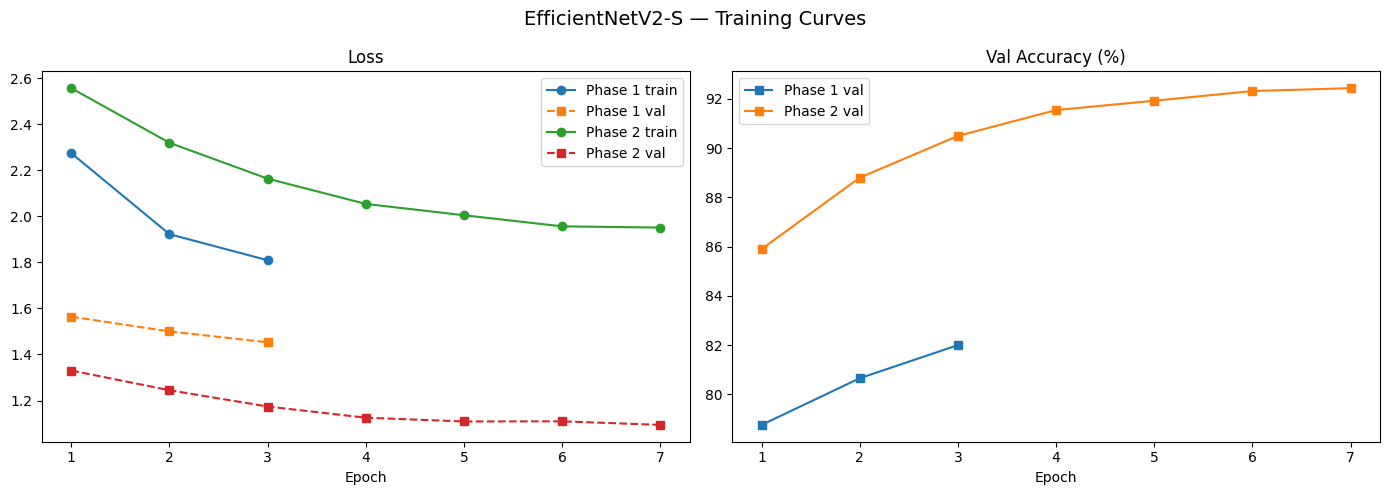

Saved training_curves.png


In [18]:
# ── 11. Training Curves ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt

df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for phase, grp in df.groupby("phase"):
    label = f"Phase {phase}"
    x = grp["epoch"].values  # ← actual epoch numbers, not reset to 0
    axes[0].plot(x, grp["tr_loss"], marker="o", label=f"{label} train")
    axes[0].plot(x, grp["vl_loss"], marker="s", linestyle="--", label=f"{label} val")
    axes[1].plot(x, grp["vl_acc"] * 100, marker="s", label=f"{label} val")

axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].set_title("Val Accuracy (%)"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.suptitle("EfficientNetV2-S — Training Curves", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(CFG["save_dir"], "training_curves.png"), dpi=150)
plt.show()
print("Saved training_curves.png")

## TTA Inference (Test-Time Augmentation)

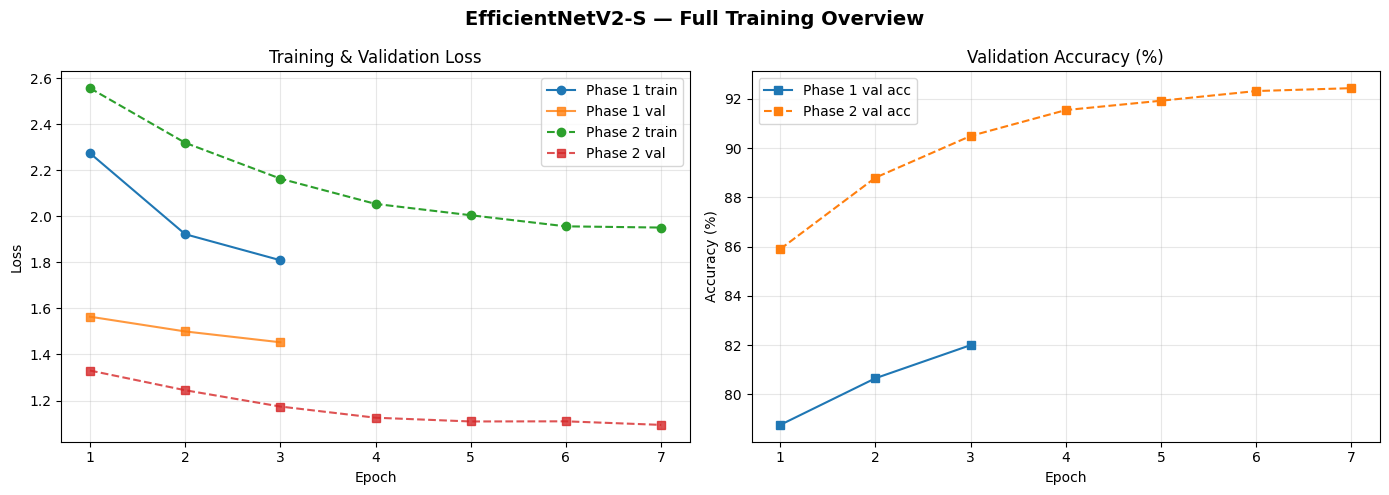

Saved report_fig1_overview.png


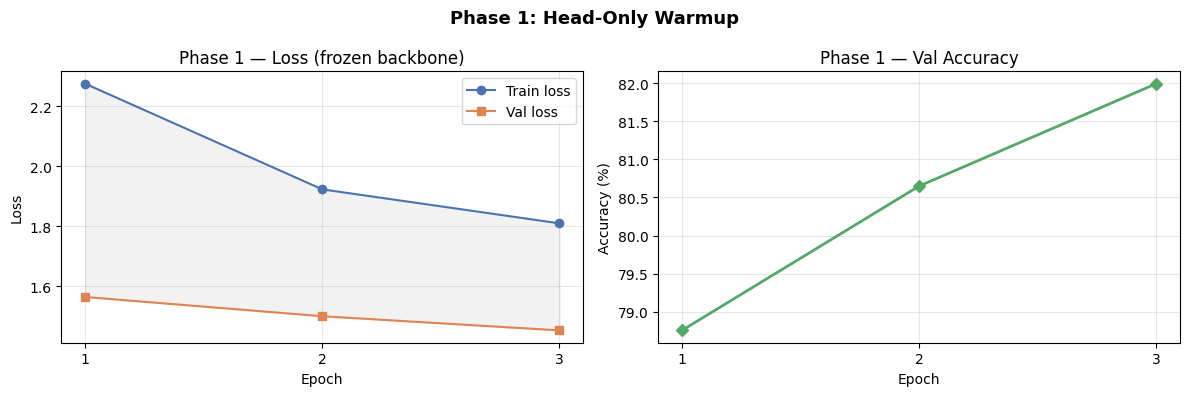

Saved report_fig2_phase1.png


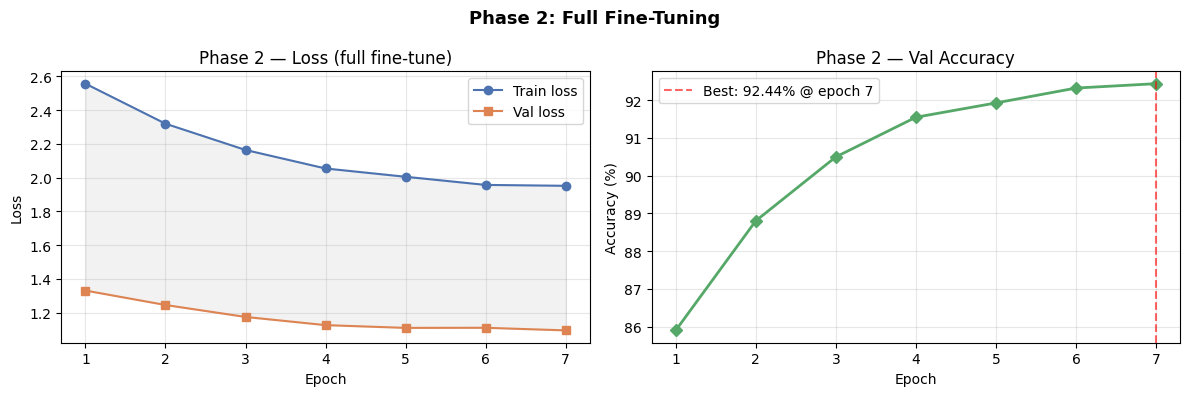

Saved report_fig3_phase2.png


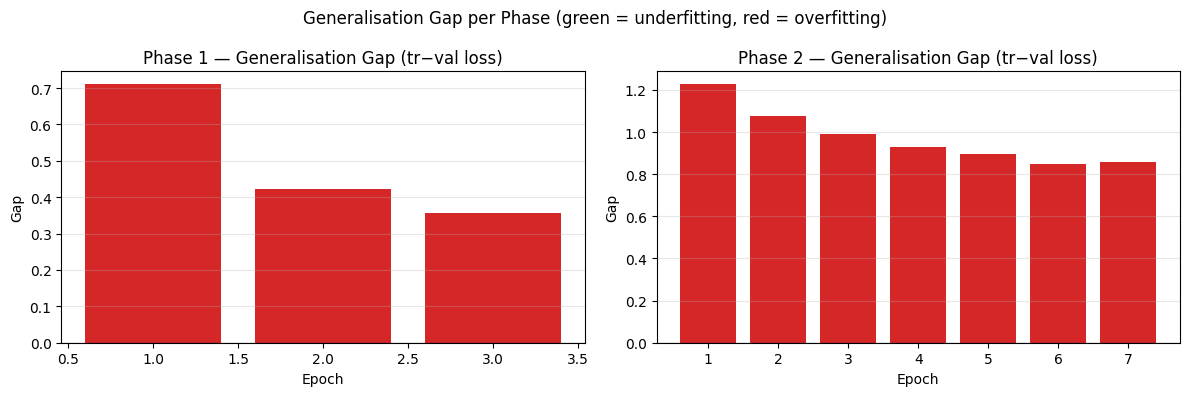

Saved report_fig4_gap.png


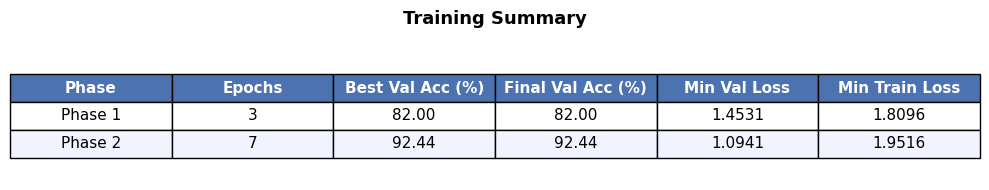

Saved report_fig5_summary_table.png

REPORT FIGURES SAVED:
  report_fig1_overview.png    — full training overview
  report_fig2_phase1.png      — phase 1 detail
  report_fig3_phase2.png      — phase 2 detail
  report_fig4_gap.png         — generalisation gap
  report_fig5_summary_table.png — stats table


In [ ]:
# ── 12. Report Visualisations ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np, pandas as pd

df = pd.DataFrame(history)
p1 = df[df["phase"] == 1].reset_index(drop=True)
p2 = df[df["phase"] == 2].reset_index(drop=True)

# ── Helper ───────────────────────────────────────────────────────────────────
SAVE = CFG["save_dir"]
COLORS = {"train": "#4C72B0", "val": "#DD8452", "acc": "#55A868",
          "p1": "#9467BD", "p2": "#E377C2"}

# ── Fig 1 : Full training overview (loss + accuracy) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for phase_df, phase_label, ls in [(p1, "Phase 1", "-"), (p2, "Phase 2", "--")]:
    ep = phase_df["epoch"].values
    axes[0].plot(ep, phase_df["tr_loss"], marker="o", ls=ls, label=f"{phase_label} train")
    axes[0].plot(ep, phase_df["vl_loss"], marker="s", ls=ls, alpha=0.8, label=f"{phase_label} val")
    axes[1].plot(ep, phase_df["vl_acc"] * 100, marker="s", ls=ls, label=f"{phase_label} val acc")
axes[0].set_title("Training & Validation Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title("Validation Accuracy (%)"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle("EfficientNetV2-S — Full Training Overview", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE}/report_fig1_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved report_fig1_overview.png")

# ── Fig 2 : Phase 1 detail ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep1 = p1["epoch"].values
axes[0].plot(ep1, p1["tr_loss"], marker="o", color=COLORS["train"], label="Train loss")
axes[0].plot(ep1, p1["vl_loss"], marker="s", color=COLORS["val"],   label="Val loss")
axes[0].fill_between(ep1, p1["tr_loss"], p1["vl_loss"], alpha=0.1, color="grey")
axes[0].set_title("Phase 1 — Loss (frozen backbone)"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(ep1, p1["vl_acc"] * 100, marker="D", color=COLORS["acc"], lw=2)
axes[1].set_title("Phase 1 — Val Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)"); axes[1].grid(True, alpha=0.3)
for ax in axes:
    ax.set_xticks(ep1)
plt.suptitle("Phase 1: Head-Only Warmup", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE}/report_fig2_phase1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved report_fig2_phase1.png")

# ── Fig 3 : Phase 2 detail ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep2 = p2["epoch"].values
axes[0].plot(ep2, p2["tr_loss"], marker="o", color=COLORS["train"], label="Train loss")
axes[0].plot(ep2, p2["vl_loss"], marker="s", color=COLORS["val"],   label="Val loss")
axes[0].fill_between(ep2, p2["tr_loss"], p2["vl_loss"], alpha=0.1, color="grey")
axes[0].set_title("Phase 2 — Loss (full fine-tune)"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(ep2, p2["vl_acc"] * 100, marker="D", color=COLORS["acc"], lw=2)
best_ep = ep2[p2["vl_acc"].argmax()]
best_acc = p2["vl_acc"].max() * 100
axes[1].axvline(best_ep, color="red", ls="--", alpha=0.6, label=f"Best: {best_acc:.2f}% @ epoch {best_ep}")
axes[1].legend()
axes[1].set_title("Phase 2 — Val Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)"); axes[1].grid(True, alpha=0.3)
for ax in axes:
    ax.set_xticks(ep2)
plt.suptitle("Phase 2: Full Fine-Tuning", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE}/report_fig3_phase2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved report_fig3_phase2.png")

# ── Fig 4 : Generalisation gap (train-val loss delta) ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
gap1 = p1["tr_loss"].values - p1["vl_loss"].values
gap2 = p2["tr_loss"].values - p2["vl_loss"].values
axes[0].bar(p1["epoch"].values, gap1, color=["#2ca02c" if g <= 0 else "#d62728" for g in gap1])
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("Phase 1 — Generalisation Gap (tr−val loss)"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Gap"); axes[0].grid(True, alpha=0.3, axis="y")
axes[1].bar(p2["epoch"].values, gap2, color=["#2ca02c" if g <= 0 else "#d62728" for g in gap2])
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Phase 2 — Generalisation Gap (tr−val loss)"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Gap"); axes[1].grid(True, alpha=0.3, axis="y")
plt.suptitle("Generalisation Gap per Phase (green = underfitting, red = overfitting)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{SAVE}/report_fig4_gap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved report_fig4_gap.png")

# ── Fig 5 : Summary stats table ───────────────────────────────────────────────
rows = []
for phase_id, phase_df in [(1, p1), (2, p2)]:
    rows.append({
        "Phase": f"Phase {phase_id}",
        "Epochs": len(phase_df),
        "Best Val Acc (%)": f"{phase_df["vl_acc"].max()*100:.2f}",
        "Final Val Acc (%)": f"{phase_df["vl_acc"].iloc[-1]*100:.2f}",
        "Min Val Loss":       f"{phase_df["vl_loss"].min():.4f}",
        "Min Train Loss":     f"{phase_df["tr_loss"].min():.4f}",
    })
summary_df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 2))
ax.axis("off")
tbl = ax.table(cellText=summary_df.values, colLabels=summary_df.columns,
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 2)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#4C72B0"); cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#f0f4ff")
plt.title("Training Summary", fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(f"{SAVE}/report_fig5_summary_table.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved report_fig5_summary_table.png")
print("\n" + "="*60)
print("REPORT FIGURES SAVED:")
print("  report_fig1_overview.png    — full training overview")
print("  report_fig2_phase1.png      — phase 1 detail")
print("  report_fig3_phase2.png      — phase 2 detail")
print("  report_fig4_gap.png         — generalisation gap")
print("  report_fig5_summary_table.png — stats table")


In [20]:
# ── 12. TTA Inference (Test-Time Augmentation) ────────────────────────────────
from torchvision.transforms.functional import five_crop

idx_to_class = {v: k for k, v in class_to_idx.items()}
model.load_state_dict(torch.load(os.path.join(CFG["save_dir"], "best_model.pth"), weights_only=True))
model.eval()

S = CFG["img_size"]
tta_tfm = T.Compose([
    T.Resize(int(S * 1.07), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(IMG_MEAN, IMG_STD),
])

def predict_tta(img_path):
    img = Image.open(img_path).convert("RGB")
    base = tta_tfm(img)
    crops = five_crop(base, S)
    batch = torch.stack(crops).to(DEVICE)
    with torch.no_grad(), torch.autocast(device_type=DEVICE.type):  # ← fixed autocast
        logits = model(batch)
    probs = torch.softmax(logits, dim=1).mean(0)
    return probs.cpu()

# Filter out any bad files from val_paths before sampling
clean_val = [(p, l) for p, l in zip(val_paths, val_labels) if not os.path.basename(p).startswith("._")]
sample_indices = random.sample(range(len(clean_val)), 5)
print("TTA Predictions (5-crop):")
for i in sample_indices:
    path, true_idx = clean_val[i]
    probs = predict_tta(path)
    pred_idx = probs.argmax().item()
    confidence = probs[pred_idx].item()
    status = "✅" if pred_idx == true_idx else "❌"
    print(f"{status} True: {idx_to_class[true_idx]:<25} | Pred: {idx_to_class[pred_idx]:<25} | Conf: {confidence*100:.1f}%")

TTA Predictions (5-crop):
✅ True: garlic naan               | Pred: garlic naan               | Conf: 82.4%
✅ True: samosa                    | Pred: samosa                    | Conf: 67.4%
✅ True: palak paneer              | Pred: palak paneer              | Conf: 65.0%
✅ True: pav bhaji                 | Pred: pav bhaji                 | Conf: 70.7%
✅ True: masala dosa               | Pred: masala dosa               | Conf: 74.9%


## Output Summary

In [21]:
# ── 13. Output Summary ───────────────────────────────────────────────────────
import os

save_dir = CFG["save_dir"]
print("=" * 60)
print(f"ALL SAVED OUTPUTS  →  {save_dir}")
print("=" * 60)

# Expected files with descriptions
manifest = {
    "best_phase1.pth":               "Phase 1 best model weights (frozen backbone)",
    "best_model.pth":                "Phase 2 best model weights (full fine-tune) ← use for inference",
    "training_state.pth":            "Optimizer state + config + class map + history",
    "class_to_idx.json":             "Class name → index mapping",
    "history.csv":                   "Per-epoch metrics (phase, epoch, tr_loss, vl_loss, vl_acc)",
    "training_curves.png":           "Quick loss + accuracy overview",
    "report_fig1_overview.png":      "Report: full training overview",
    "report_fig2_phase1.png":        "Report: phase 1 detail",
    "report_fig3_phase2.png":        "Report: phase 2 detail",
    "report_fig4_gap.png":           "Report: generalisation gap",
    "report_fig5_summary_table.png": "Report: summary stats table",
}

total_mb = 0.0
for fname, desc in manifest.items():
    fpath = os.path.join(save_dir, fname)
    if os.path.exists(fpath):
        mb = os.path.getsize(fpath) / 1e6
        total_mb += mb
        print(f"  ✅  {fname:<40}  {mb:6.1f} MB   {desc}")
    else:
        print(f"  ❌  {fname:<40}  MISSING          {desc}")

print("-" * 60)
print(f"  Total: {total_mb:.1f} MB")
print("=" * 60)
print("\nTo load the best model for inference:")
print("  import torch, timm, json")
print(f"  state   = torch.load('{save_dir}/best_model.pth', weights_only=True)")
print(f"  c2i     = json.load(open('{save_dir}/class_to_idx.json'))")
print(f"  model   = timm.create_model('{{}}'.format(CFG['model_name']),")
print(f"                num_classes=len(c2i), pretrained=False)")
print(f"  model.load_state_dict(state)")
print(f"  model.eval()")


ALL SAVED OUTPUTS  →  /kaggle/working/efficientnetv2_s
  ✅  best_phase1.pth                             82.0 MB   Phase 1 best model weights (frozen backbone)
  ✅  best_model.pth                              82.0 MB   Phase 2 best model weights (full fine-tune) ← use for inference
  ✅  training_state.pth                         162.6 MB   Optimizer state + config + class map + history
  ✅  class_to_idx.json                            0.0 MB   Class name → index mapping
  ✅  history.csv                                  0.0 MB   Per-epoch metrics (phase, epoch, tr_loss, vl_loss, vl_acc)
  ✅  training_curves.png                          0.1 MB   Quick loss + accuracy overview
  ✅  report_fig1_overview.png                     0.1 MB   Report: full training overview
  ✅  report_fig2_phase1.png                       0.1 MB   Report: phase 1 detail
  ✅  report_fig3_phase2.png                       0.1 MB   Report: phase 2 detail
  ✅  report_fig4_gap.png                          0.1 MB   Repor